# Clean Card Detection Pipeline

This notebook keeps the workflow readable. The detection logic lives in `card_detection/`, while the notebook chooses inputs, optionally tunes thresholds, and displays results.

In [8]:
from pathlib import Path

from card_detection import (
    DEFAULT_COLORS,
    CardDetectionPaths,
    create_special_tuner,
    create_threshold_tuner,
    detect_cards_in_image,
    display_reference_card_labeler,
    load_card_template,
    load_color_thresholds,
    load_gray_threshold,
    load_image,
    load_rectangle_settings,
    load_special_settings,
    load_threshold_rectangle_settings,
    parse_hsv_file,
    show_detection_result,
    show_images,
    train_images,
)


## Inputs

Choose the image and the color used by the optional tuner. The all-color detector uses the saved threshold files for every color.

Image: L1000982.jpg
Detection colors: ('blue', 'red', 'yellow', 'black', 'green')
Special detection: True
Rectangle settings: {'min_area': 1000, 'close_size': 2, 'close_iter': 0, 'min_fill': 15, 'min_score': 150, 'angle_step': 2, 'max_outside': 4, 'max_candidates_per_region': 12}
Special settings: {'yellow_min_radius': 15, 'yellow_max_radius': 30, 'yellow_min_circularity': 40, 'yellow_min_fill': 51, 'black_min_area': 1000, 'black_min_fill': 80, 'black_max_long_side': 80, 'black_min_short_side': 30, 'black_max_aspect': 3}
Removal convex mask: True
Detection progress: True


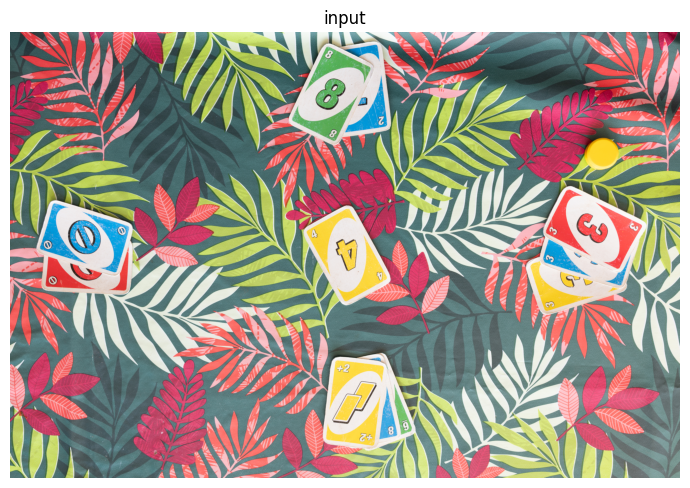

In [9]:
BASE_DIR = Path.cwd()
PATHS = CardDetectionPaths(BASE_DIR)

IMAGE_NAME = "L1000982.jpg"
TUNER_COLOR = "green"
DETECTION_COLORS = DEFAULT_COLORS  # Use (TUNER_COLOR,) to compare the final detector with the tuner color only.
SCALE = 0.25
REMOVAL_MAKE_CONVEX = True
SHOW_DETECTION_PROGRESS = True

image_path = PATHS.train_dir / IMAGE_NAME
if not image_path.exists():
    available_images = train_images(PATHS.train_dir)
    if not available_images:
        raise FileNotFoundError(f"No training images found in {PATHS.train_dir}")
    image_path = available_images[0]

detect_special = image_path.parent.resolve() != PATHS.reference.resolve()

image_bgr, image_rgb = load_image(image_path)
card_template_mask = load_card_template(PATHS.card_template_mask)
color_thresholds = load_color_thresholds(PATHS, DEFAULT_COLORS)
rectangle_defaults = load_rectangle_settings(PATHS.rectangle_settings)
rectangle_settings = load_threshold_rectangle_settings(PATHS.threshold_rectangle_settings, rectangle_defaults)
special_settings = load_special_settings(PATHS.special_settings)

print("Image:", image_path.name)
print("Detection colors:", DETECTION_COLORS)
print("Special detection:", detect_special)
print("Rectangle settings:", rectangle_settings)
print("Special settings:", special_settings)
print("Removal convex mask:", REMOVAL_MAKE_CONVEX)
print("Detection progress:", SHOW_DETECTION_PROGRESS)
show_images([("input", image_rgb)], cols=1, figsize=(7, 7))


## Optional Tuner

Set `RUN_TUNER = True` to open the threshold and rectangle controls. Saving updates the same text files used by the detector.

In [ ]:
RUN_TUNER = True  

if RUN_TUNER:
    use_gray = not PATHS.hsv_file(TUNER_COLOR).exists() and PATHS.gray_file(TUNER_COLOR).exists()
    hsv_ranges = [] if use_gray else parse_hsv_file(PATHS.hsv_file(TUNER_COLOR))
    gray_settings = load_gray_threshold(PATHS.gray_file(TUNER_COLOR))

    tuner = create_threshold_tuner(
        image_bgr=image_bgr,
        image_rgb=image_rgb,
        color=TUNER_COLOR,
        hsv_ranges=hsv_ranges,
        gray_settings=gray_settings,
        rectangle_settings=rectangle_settings,
        card_template_mask=card_template_mask,
        hsv_path=PATHS.hsv_file(TUNER_COLOR),
        gray_path=PATHS.gray_file(TUNER_COLOR),
        rectangle_settings_path=PATHS.threshold_rectangle_settings,
        use_gray_threshold=use_gray,
        scale=SCALE,
    )


## Optional Specials Tuner

Set `RUN_SPECIAL_TUNER = True` to tune token/special shape thresholds. Saving updates `special_detection_set.txt`, which is used by the final detector.

In [4]:
RUN_SPECIAL_TUNER = True

if RUN_SPECIAL_TUNER:
    special_tuner = create_special_tuner(
        image_bgr=image_bgr,
        image_rgb=image_rgb,
        color_thresholds=color_thresholds,
        rectangle_settings=rectangle_settings,
        card_template_mask=card_template_mask,
        special_settings=special_settings,
        special_settings_path=PATHS.special_settings,
        yellow_hsv_path=PATHS.hsv_file("yellow"),
        black_gray_path=PATHS.gray_file("black"),
        scale=SCALE,
    )


## Detect Cards

The final detector reloads saved threshold files first. If you tuned sliders but did not press save, those unsaved widget values are only visible in the tuner preview.

Each color is fitted independently. Scores are only used to order candidates within the same color, so a candidate from one color cannot suppress a candidate from another color.


In [5]:
color_thresholds = load_color_thresholds(PATHS, DEFAULT_COLORS)
rectangle_defaults = load_rectangle_settings(PATHS.rectangle_settings)
rectangle_settings = load_threshold_rectangle_settings(PATHS.threshold_rectangle_settings, rectangle_defaults)
special_settings = load_special_settings(PATHS.special_settings)

result = detect_cards_in_image(
    image_bgr=image_bgr,
    image_rgb=image_rgb,
    color_thresholds=color_thresholds,
    rectangle_settings=rectangle_settings,
    card_template_mask=card_template_mask,
    colors=DETECTION_COLORS,
    scale=SCALE,
    detect_special=detect_special,
    special_settings=special_settings,
    removal_make_convex=REMOVAL_MAKE_CONVEX,
    show_progress=SHOW_DETECTION_PROGRESS,
)

print("Detection colors:", DETECTION_COLORS)
print("Rectangle settings:", rectangle_settings)
print("Special settings:", special_settings)
print("Special detection:", detect_special)
print("Removal convex mask:", REMOVAL_MAKE_CONVEX)
print("Detection progress:", SHOW_DETECTION_PROGRESS)
print(f"Detected cards: {len(result.cards)}")
for row in result.rows:
    kind = row.get("kind", "card")
    if kind == "card":
        print(f"#{row['rank']}: {kind} {row['color']} score={row['score']:.1f} fill={row['fill']:.2f} bbox={row['bbox']}")
    else:
        print(f"#{row['rank']}: {kind} {row['color']} area={row.get('area', 0):.1f} fill={row['fill']:.2f} bbox={row['bbox']}")

red_rejections = [item for item in getattr(result, "rejected", []) if item["color"] == "red"]
print(f"Rejected red candidates: {len(red_rejections)}")
for index, item in enumerate(red_rejections, start=1):
    print(
        f"red rejected #{index}: {item['reason']} score={item['score']:.1f} "
        f"fill={item['fill']:.2f} outside={item['outside']:.2f} bbox={item['bbox']}"
    )


Detecting specials


black candidates:   0%|          | 0/1 [00:00<?, ?it/s]

black candidates: threshold/cleanup black
black candidates: template matching black


blue candidates:   0%|          | 0/1 [00:00<?, ?it/s]

blue candidates: threshold/cleanup blue
blue candidates: template matching blue
Extracting #2 blue
Extracting #3 blue
Extracting #4 blue
Extracting #5 blue


...

red candidates: threshold/cleanup red
red candidates: template matching red
Extracting #6 red
Extracting #7 red


yellow candidates:   0%|          | 0/1 [00:00<?, ?it/s]

yellow candidates: threshold/cleanup yellow
yellow candidates: template matching yellow
Extracting #8 yellow
Extracting #9 yellow
Extracting #10 yellow


green candidates:   0%|          | 0/1 [00:00<?, ?it/s]

green candidates: threshold/cleanup green
green candidates: template matching green
Extracting #11 green
Detection colors: ('blue', 'red', 'yellow', 'black', 'green')
Rectangle settings: {'min_area': 1000, 'close_size': 2, 'close_iter': 0, 'min_fill': 15, 'min_score': 150, 'angle_step': 2, 'max_outside': 4, 'max_candidates_per_region': 12}
Special settings: {'yellow_min_radius': 15, 'yellow_max_radius': 30, 'yellow_min_circularity': 40, 'yellow_min_fill': 51, 'black_min_area': 1000, 'black_min_fill': 80, 'black_max_long_side': 80, 'black_min_short_side': 30, 'black_max_aspect': 3}
Special detection: True
Removal convex mask: True
Detection progress: True
Detected cards: 10
#1: yellow_circle yellow area=1694.5 fill=0.82 bbox=(858, 160, 51, 46)
#2: card blue score=2460.2 fill=0.75 bbox=(40, 251, 142, 110)
#3: card blue score=974.7 fill=0.47 bbox=(473, 18, 91, 134)
#4: card blue score=601.8 fill=0.37 bbox=(794, 273, 140, 106)
#5: card blue score=204.1 fill=0.22 bbox=(477, 481, 103, 139)
#

## Result

The debug masks show each color threshold after cleanup. The overlay shows accepted detections, and the final grid shows extracted cards.

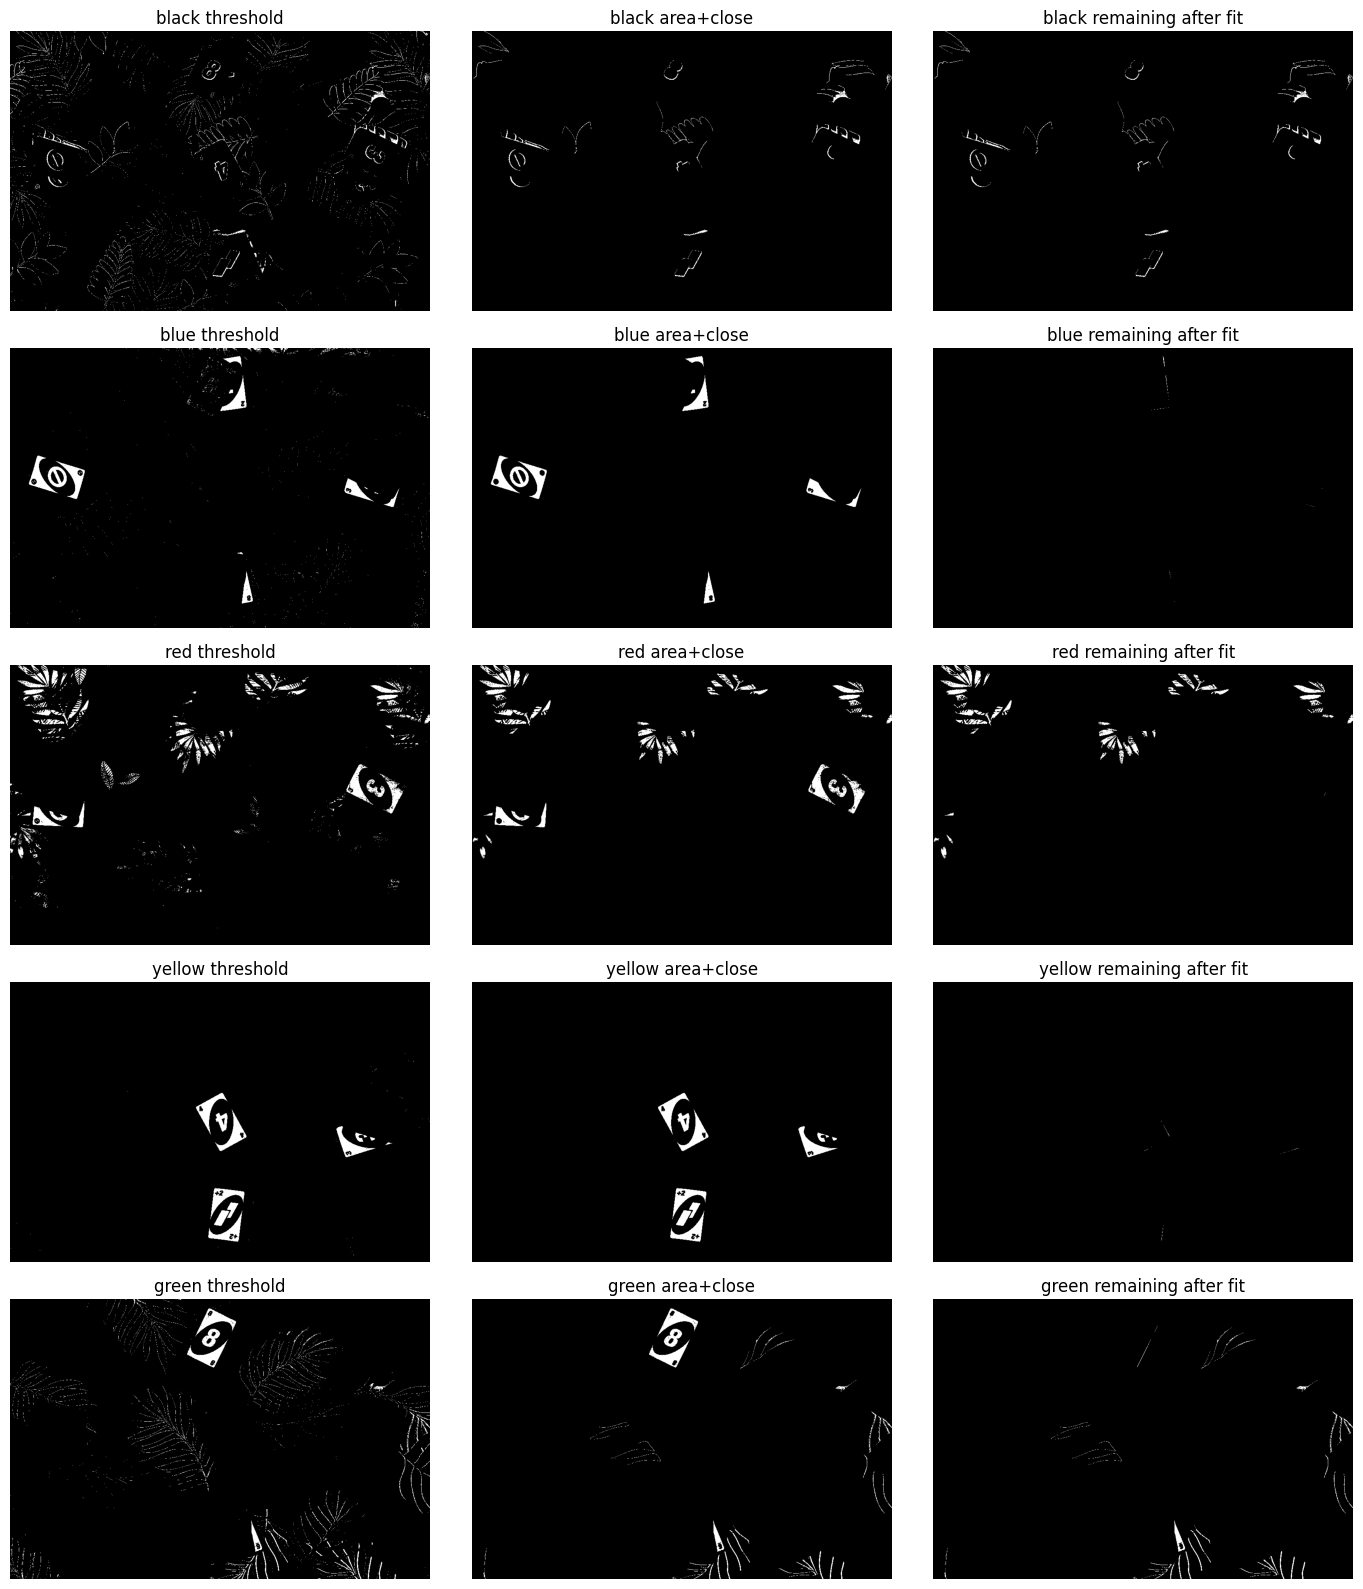

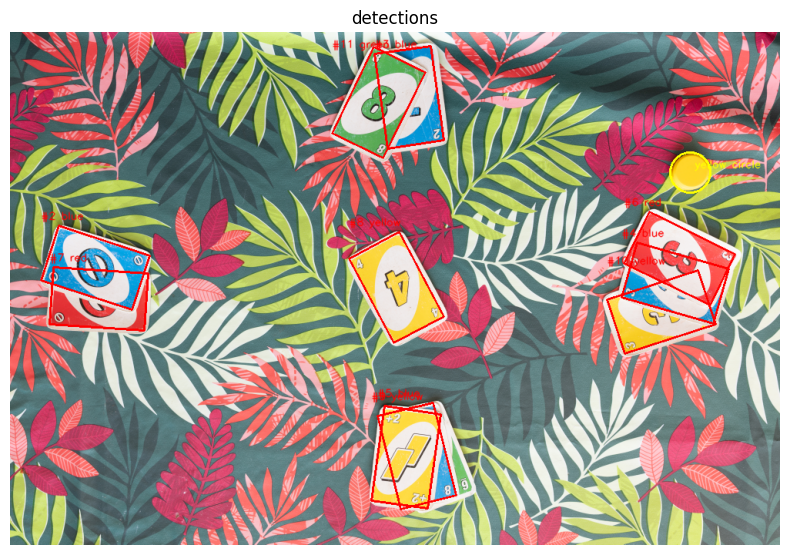

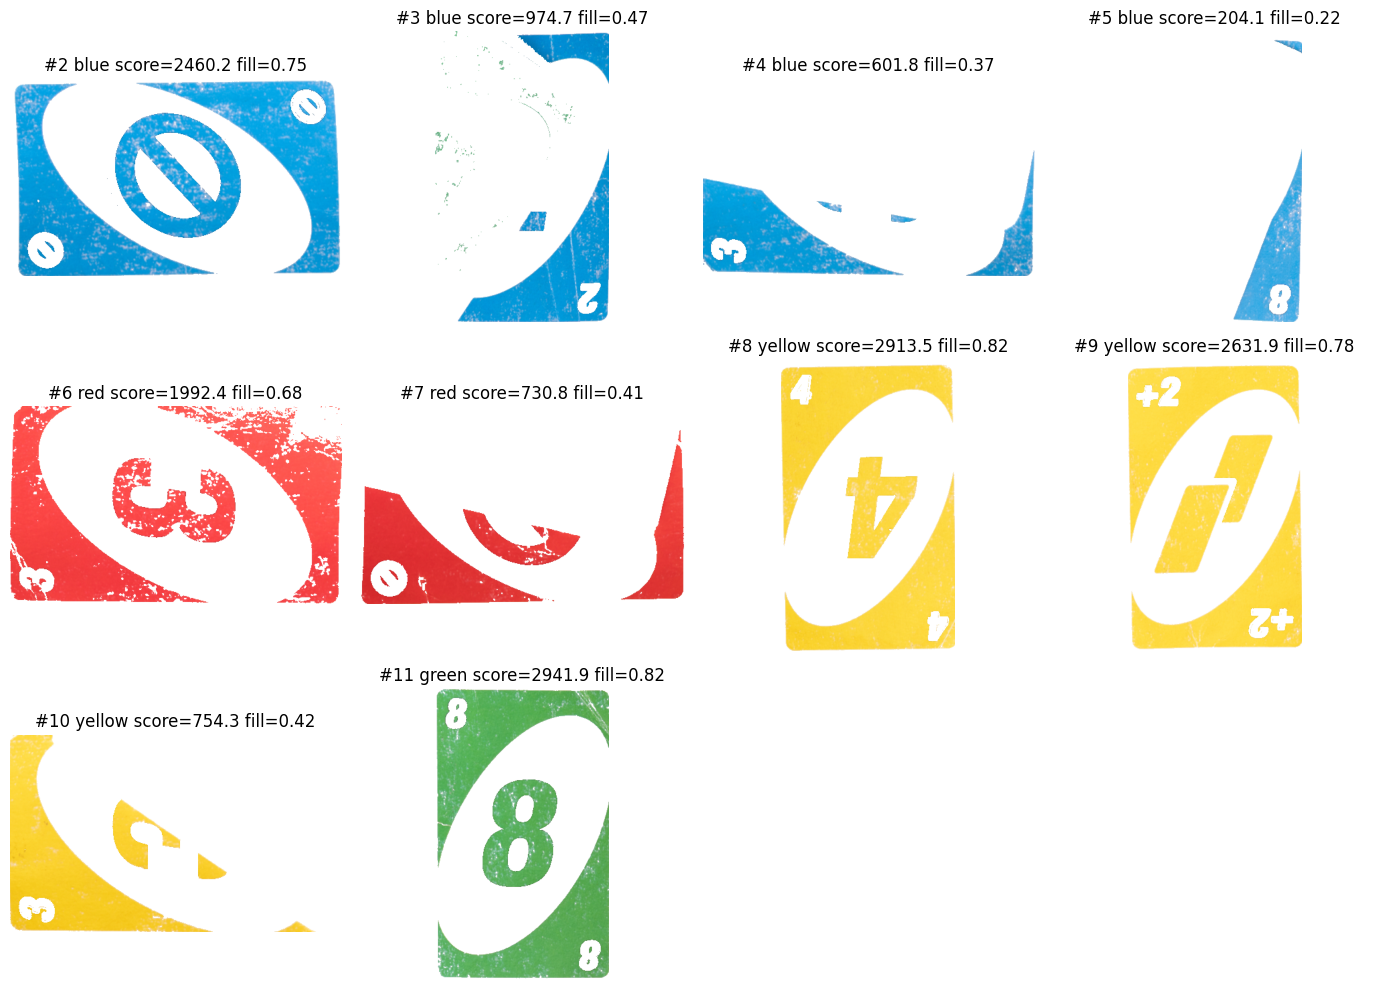

In [6]:
show_detection_result(result)


## Extract Reference Cards

Run this cell to detect cards in the reference images, label each crop, and save the labeled crops in `cards`.

In [7]:
RUN_REFERENCE_CARD_EXPORT = True

if RUN_REFERENCE_CARD_EXPORT:
    display_reference_card_labeler(
        PATHS,
        color_thresholds=color_thresholds,
        rectangle_settings=rectangle_settings,
        card_template_mask=card_template_mask,
        scale=SCALE,
        colors=DEFAULT_COLORS,
    )


KeyboardInterrupt: 